In [ ]:
# import pandas as pd
# import numpy as np
# import matplotlib.pyplot as plt
# import html
# from sklearn.feature_extraction.text import TfidfVectorizer
# from sklearn.decomposition import PCA
# from scipy.cluster.hierarchy import linkage, dendrogram, cut_tree

# # --- YOUR EXISTING CODE ---
# data = pd.read_csv("../q/shortened_dataset.csv")

# # # We drop empty descriptions and sample 50 games so the graph is readable
# # data = data.dropna(subset=['description']).sample(50, random_state=42).copy()

# # Set the index to 'name' so the game titles appear at the bottom of the dendrogram
# data.set_index('name', inplace=True) 

# descs = data['description']
# data['description'] = descs.astype(str).apply(lambda x: html.unescape(x) if isinstance(x, str) else x)
# # --------------------------

# # 1. Text Vectorization (Convert descriptions to numbers)
# # This creates a matrix based on word importance (ignoring common English stop words)
# tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
# X_tfidf = tfidf.fit_transform(data['description']).toarray()
# X = pd.DataFrame(X_tfidf, index=data.index, columns=tfidf.get_feature_names_out())

# # 2. Dimensionality Reduction (From your IPYNB notebook)
# # Text data creates hundreds of columns; PCA reduces this down to the top 10 most important components
# pca = PCA(n_components=10, random_state=1337)
# X_pca = pd.DataFrame(pca.fit_transform(X), index=X.index)

# # 3. Hierarchical Clustering (Linkage)
# # Using Ward's method to minimize variance within clusters, as seen in your notebook
# Z_ward = linkage(X_pca, method='ward', optimal_ordering=True)

# # 4. Plot the Dendrogram
# fig, ax = plt.subplots(figsize=(12, 6))

# # Generate the tree
# ward_dendrogram = dendrogram(Z_ward, ax=ax, labels=data.index.tolist(), leaf_rotation=90)

# # Clean up the graph visually
# ax.spines[['top', 'right']].set_visible(False)
# ax.set_ylabel("Distance", fontsize=12)
# fig.suptitle("Hierarchical Clustering Dendrogram (Ward)", fontsize=14, weight='bold')

# plt.tight_layout()
# plt.show()

# # 5. Extract Cluster Labels (Using cut_tree from your notebook)
# # Let's slice the tree to form 4 distinct clusters
# ward_labels = cut_tree(Z_ward, n_clusters=4).flatten()
# data['cluster'] = ward_labels

# # View the final dataset with the assigned clusters!
# print(data[['cluster', 'Average']].head(10))

In [2]:
import pandas as pd
import html
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, cut_tree

# 1. Load the FULL dataset (No sampling)
data = pd.read_csv("../q/shortened_dataset.csv")
data = data.dropna(subset=['description']).copy()
data.set_index('name', inplace=True)

# Clean the text
descs = data['description']
data['description'] = descs.astype(str).apply(lambda x: html.unescape(x) if isinstance(x, str) else x)

# 2. Vectorize & PCA (Very Fast)
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X = pd.DataFrame(tfidf.fit_transform(data['description']).toarray(), index=data.index)

pca = PCA(n_components=10, random_state=1337)
X_pca = pca.fit_transform(X)

print("Starting heavy clustering math... this will take ~30 seconds.")

# 3. Clustering (CRITICAL: optimal_ordering must be False!)
Z_ward = linkage(X_pca, method='ward', optimal_ordering=False)

# 4. Extract Labels (NO graphing!)
data['cluster'] = cut_tree(Z_ward, n_clusters=4).flatten()

# Save the full results
data.to_csv("full_10000_clustered_games.csv")
print("Finished! All games are now clustered.")

Starting heavy clustering math... this will take ~30 seconds.
Finished! All games are now clustered.


Loading data...
Cleaning text...
Vectorizing text and applying PCA...
Performing hierarchical clustering (this will take ~10-20 seconds with optimal_ordering=False)...
Plotting the massive dendrogram...
Done! Saved as full_dataset_dendrogram.png


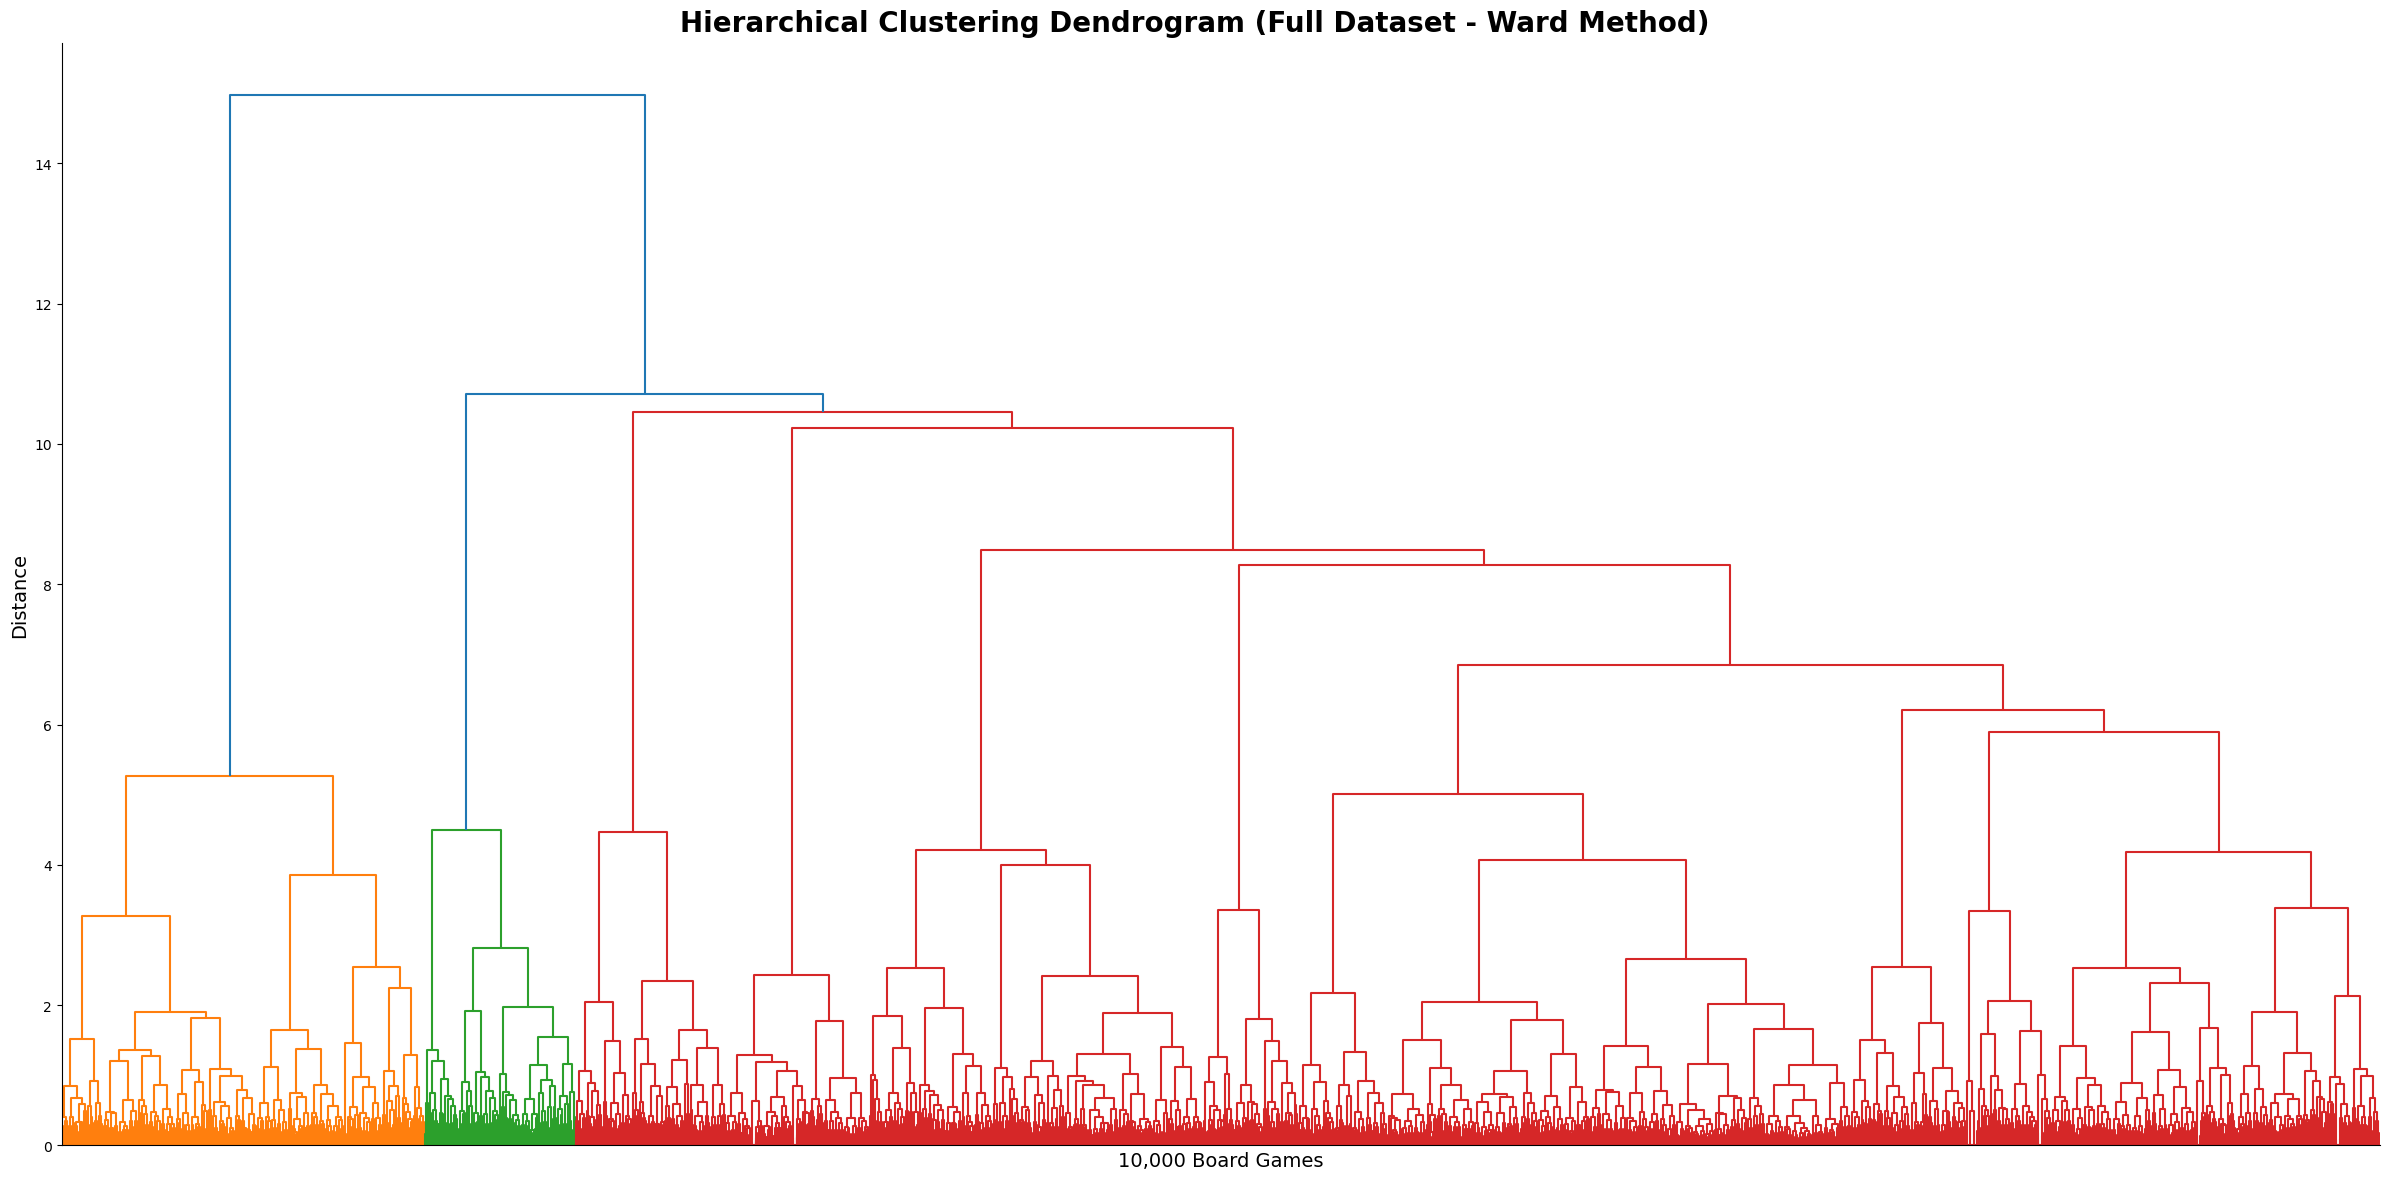

In [4]:
import pandas as pd
import html
import matplotlib.pyplot as plt
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import PCA
from scipy.cluster.hierarchy import linkage, dendrogram
import sys

# Increase recursion depth for deep trees
sys.setrecursionlimit(100000)

print("Loading data...")
data = pd.read_csv("../q/shortened_dataset.csv")
data = data.dropna(subset=['description']).copy()
data.set_index('name', inplace=True)

print("Cleaning text...")
data['description'] = data['description'].astype(str).apply(lambda x: html.unescape(x) if isinstance(x, str) else x)

print("Vectorizing text and applying PCA...")
tfidf = TfidfVectorizer(stop_words='english', max_features=1000)
X = tfidf.fit_transform(data['description']).toarray()

pca = PCA(n_components=10, random_state=1337)
X_pca = pca.fit_transform(X)

print("Performing hierarchical clustering (this will take ~10-20 seconds with optimal_ordering=False)...")
Z_ward = linkage(X_pca, method='ward', optimal_ordering=False)

print("Plotting the massive dendrogram...")
# Use a very large figure size to fit the thousands of branches
fig, ax = plt.subplots(figsize=(24, 12))

# We use no_labels=True. If matplotlib tries to render 10,000 individual text labels, 
# it will physically run out of memory and crash the kernel. The tree itself will still render all 10,000 leaves.
dendrogram(Z_ward, ax=ax, no_labels=True)

ax.spines[['top', 'right']].set_visible(False)
ax.set_ylabel("Distance", fontsize=14)
ax.set_xlabel("10,000 Board Games", fontsize=14)
fig.suptitle("Hierarchical Clustering Dendrogram (Full Dataset - Ward Method)", fontsize=20, weight='bold')

plt.tight_layout()
plt.savefig("full_dataset_dendrogram.png", dpi=300)
print("Done! Saved as full_dataset_dendrogram.png")